# Support Vector Machines

This note contains all the code examples of my SVM learning process.

Import packages:

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets as sk_datasets
import sklearn.svm as svm_models
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

## Linear SVM

Let's try to train simple linear SVM on Iris dataset, shown in `3-Training-Linear-Models.ipynb`

In [102]:
iris = sk_datasets.load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [103]:
iris.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [104]:
X = iris.data[["sepal length (cm)", "sepal width (cm)"]].values
y = iris.target == 2

In [105]:
lin_svm = svm_models.LinearSVC()
lin_svm.fit(X, y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [106]:
new_iris_data = [[6.5, 1.7], [5.0, 1.5]]
lin_svm.predict(new_iris_data)

array([ True, False])

In [107]:
lin_svm.decision_function(new_iris_data)

array([ 0.55808211, -0.36219434])

## Non-Linear SVM Classification

If our data cannot be linearly separable, we can artificially supplement our dataset with polynomial features _(discussed in 3-Training-Linear-Models.ipynb)_

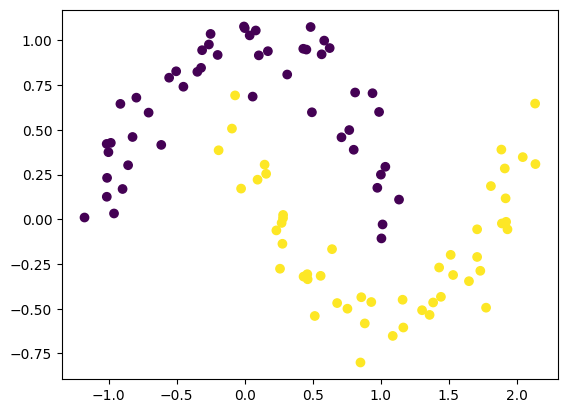

In [108]:
X, y = sk_datasets.make_moons(n_samples=100, noise=0.1)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [126]:
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    svm_models.LinearSVC(C=1.0),
)
polynomial_svm_clf.fit(X, y)

,steps,"[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


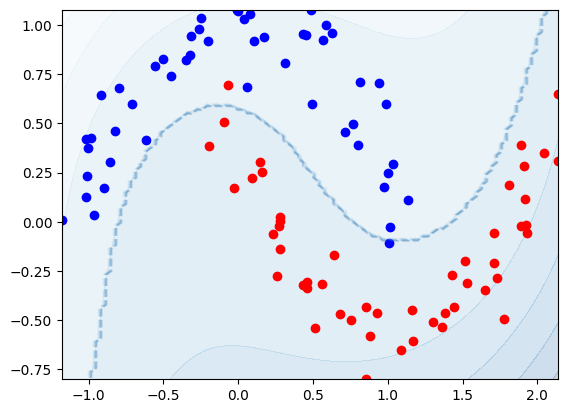

In [127]:
def plot_dataset(X, y):
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

def plot_svm(svm, axes):
    X_0, X_1 = np.linspace(axes[0], axes[1], 100), np.linspace(axes[2], axes[3], 100)

    # Contains every possible point of the generated X_0 and X_1 coordinates
    X0s, X1s = np.meshgrid(X_0, X_1)
    X = np.c_[X0s.ravel(), X1s.ravel()]

    # Reshaping to make the same shape as our coordinate grid
    y_pred = svm.predict(X).reshape(X0s.shape)
    y_decision = svm.decision_function(X).reshape(X0s.shape)

    plt.contourf(X0s, X1s, y_decision, cmap="Blues", alpha=0.2) # Decision function values map
    plt.contour(X0s, X1s, y_pred, cmap="Blues", alpha=0.2, linestyles=["--"]) # Decision boundary


plot_svm(polynomial_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_dataset(X, y)

On the plot, we can see that the model correctly got the data nature. Plot like this can help us to see how regularization $C$, number of freedom degrees are affecting the model.

> The plot is basically a projection of the 3D figure, where $x, y$ are our features, and $z$ is a result of a decision_function.

Here is example of how overfitting model would look like on the same dataset:

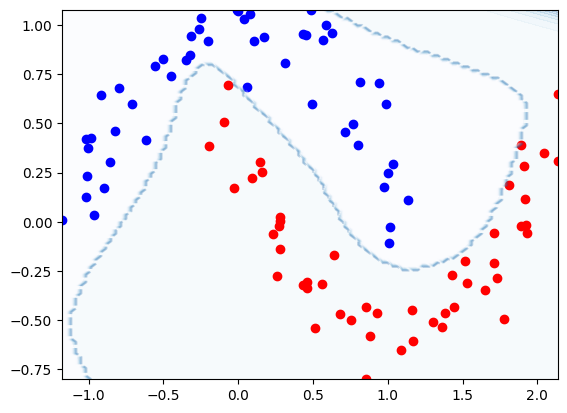

In [144]:
polynomial_svm_clf_overfit = make_pipeline(
    PolynomialFeatures(degree=30),
    StandardScaler(),
    svm_models.LinearSVC(C=10.0, max_iter=10000),
)
polynomial_svm_clf_overfit.fit(X, y)

plot_svm(polynomial_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_dataset(X, y)

## Polynomial Kernel

Polynomial Kernel allows you to apply kernel trick, to get same model based on polynomial features without having to add them!

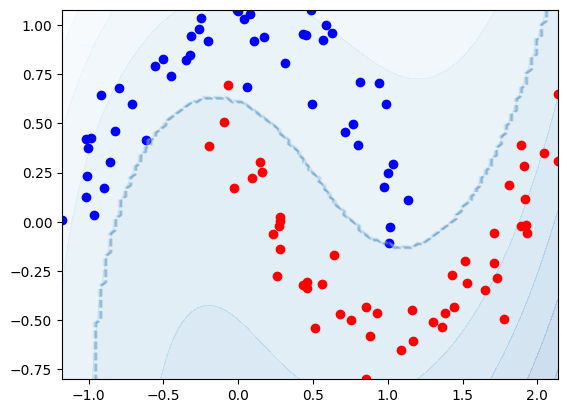

In [151]:
poly_kernel_svm_clf = svm_models.SVC(kernel="poly", degree=3, C=1.0, coef0=1)
poly_kernel_svm_clf.fit(X, y)

plot_svm(poly_kernel_svm_clf, axes=[np.min(X[:, 0]), np.max(X[:, 0]), np.min(X[:, 1]), np.max(X[:, 1])])
plot_dataset(X, y)

See? We got same model as in first plot! Without troubles with explosion of number of features

# Exercises

1. What is the fundamental idea behind support vector machines?

> SVMs trying to find the widest _gap_ _(or margin)_ between the dataset instances and decision boundary using support vectors.

2. What is a support vector?

> Basically, support vector is an $x^{(i)}$ instance of the $X$ dataset. The decision boundary tries to stay as distant from support vectors as it possible.

3. Why is it important to scale the inputs when using SVMs?

> At the training, SVM tries to minimize weights in $w$ vector. If some feature has bigger scale, it won't affect the support vectors much. So the widest margin will be smaller and the model won't generalize well

4. Can an SVM classifier output a confidence score when it classifies an instance? What about a probability?

> Yes, using `decision_function` SVM classifier can output a confidence score, the score is instance's distance from the decision boundary. Probability isn't supported out of factory, but in **SKLearn**, you can define `probability=True`, and the `SVM` class will make 5 cross-validation to get its predictions of every train's instances and train LogisticRegression to be able to return probability.

5. How can you choose between `LinearSVC`, `SVC`, and `SGDClassifier`?

> Firstly, you should try `LinearSVC`, because it's cheap and fast. If linear SVM doesn't generalize well - move onto `SVC(kernel="linear")`. If the data isn't linearly separable and the dataset small to medium size, choose another kernels, "rbf" -> "poly". If your dataset is large, try using Stochastic Gradient Descent approach to reduce compute time.

6. Say you've trained an SVM classifier with an RBF kernel, but it seems to underfit the training set. Should you increase or decrease $\gamma$ (gamma)? What about $C$?

> You should increase $\gamma$, because it will decrease similarness to their neighbors. Also, you may want to increase $C$ hyperparameter too, to make outliers fine more painful to the model.

7. What does it mean for a model to be $\epsilon$-insensitive?

> $\epsilon$-insensitive is an SVR model _(for regression tasks)_ that its support vectors don't change if you add more instances withing the margin

8. What is the point of using the kernel trick?

> The main point of using kernel trick - is to access the non-linear SVMs models _(such Polynomial or Similarity features)_ benefits without explosion in the number of features. It allows you to get the same results as not-kernelized models not modifying the dataset.

9. Train a `LinearSVC` on a linearly separable dataset. Then train an `SVC` and a `SGDClassifier` on the same dataset. See if you can get them to produce roughly the same model.
10. Train an `SVM` classifier on the wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analyses of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine's chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all three classes. What accuracy can you reach?
11. Train and fine-tune an SVM regressor on the California housing dataset. You can use the original dataset rather than the tweaked version we used in Chapter 2, which you can load using `sklearn.datasets.fetch_california_housing()`. The targets represent hundreds of thousands of dollars. Since there are over 20,000 instances, SVMs can be slow, so for hyperparameter tuning you should use far fewer instances (e.g., 2,000) to test many more hyperparameter combinations. What is your best model's RMSE?